# 1. Environment Setup & Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- MANDATORY AUTOMATION: FETCH RAW DATASET FROM GITHUB ---
DATASET_URL = "https://raw.githubusercontent.com/AbrarYasir01/automated-neural-network-pipeline/refs/heads/main/Churn_Modelling.csv"
df = pd.read_csv(DATASET_URL)

print(f"Dataset successfully fetched dynamically. Shape: {df.shape}")
df.head()

Dataset successfully fetched dynamically. Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# 1. Handle Missing Values (Imputation)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# Identify features and target (Assuming 'Exited' or last column is target)
# Adjust target column name string matching your specific CSV file if needed
X = df.iloc[:, :-1]
y = df.iloc[:, -1].values

# Drop irrelevant demographic ID columns if using Churn dataset variations
irrelevant_cols = ['RowNumber', 'CustomerId', 'Surname']
X = X.drop(columns=[col for col in irrelevant_cols if col in X.columns])

# 2. Categorical Encoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# 3. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, stratify=y, random_state=42
)

# Further split train into validation (10% of total) for hyperparameter tuning
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, stratify=y_train, random_state=42
)

# Convert arrays into PyTorch Tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

input_dim = X_train.shape[1]
print(f"Preprocessing Complete. Input Dimensions: {input_dim}")

Preprocessing Complete. Input Dimensions: 11


# 2. Shallow Neural Network Implementation

In [3]:
class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units=16, activation_fn=nn.ReLU):
        super(ShallowNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_units)
        self.activation = activation_fn()
        self.out = nn.Linear(hidden_units, 1)

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = torch.sigmoid(self.out(x))
        return x.squeeze()

# Helper function to track loss & accuracy
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            train_correct += (preds == targets).sum().item()
            train_total += targets.size(0)

        # Validation evaluation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                preds = (outputs >= 0.5).float()
                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)

        history['train_loss'].append(train_loss / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['train_acc'].append(train_correct / train_total)
        history['val_acc'].append(val_correct / val_total)

    return history

# Tune and instantiate optimized Shallow network
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

shallow_model = ShallowNN(input_dim=input_dim, hidden_units=32, activation_fn=nn.ReLU)
shallow_criterion = nn.BCELoss()
shallow_optimizer = optim.SGD(shallow_model.parameters(), lr=0.01)

print("Training Shallow Neural Network...")
shallow_history = train_model(shallow_model, train_loader, val_loader, shallow_criterion, shallow_optimizer, epochs=50)

Training Shallow Neural Network...


# 3. Deep Neural Network Implementation

In [4]:
class DeepNN(nn.Module):
    def __init__(self, input_dim, dropout_prob=0.3):
        super(DeepNN, self).__init__()
        # Three hidden layers
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x)).squeeze()

deep_model = DeepNN(input_dim=input_dim, dropout_prob=0.25)
deep_criterion = nn.BCELoss()
# Tuning step: Utilizing Adam optimizer vs SGD for deeper conversion
deep_optimizer = optim.Adam(deep_model.parameters(), lr=0.005, weight_decay=1e-5) # L2 regularization

print("Training Deep Neural Network...")
deep_history = train_model(deep_model, train_loader, val_loader, deep_criterion, deep_optimizer, epochs=50)

Training Deep Neural Network...


# 4. Required Visualizations (2x1 Comparison Matrix Matrix & Analysis)

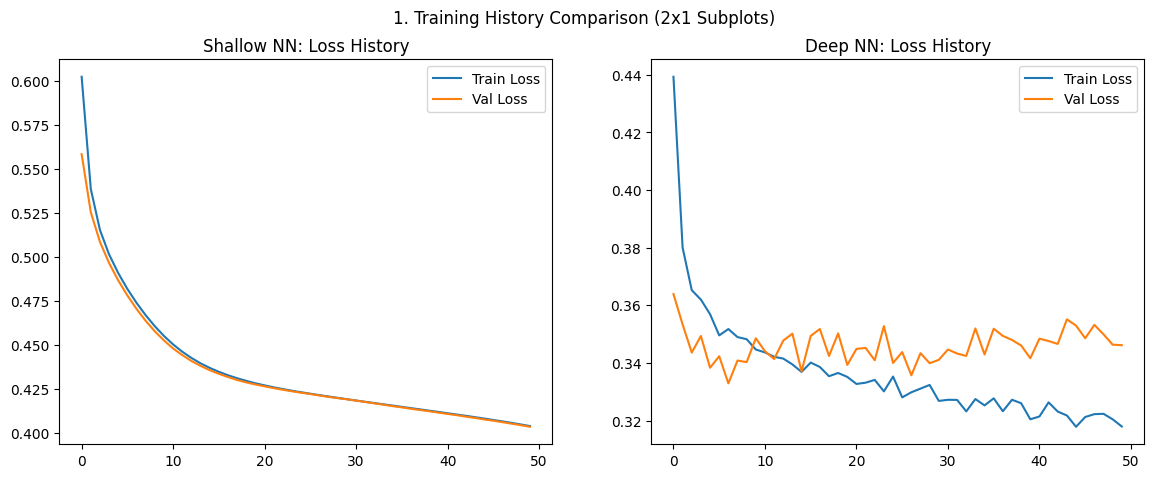

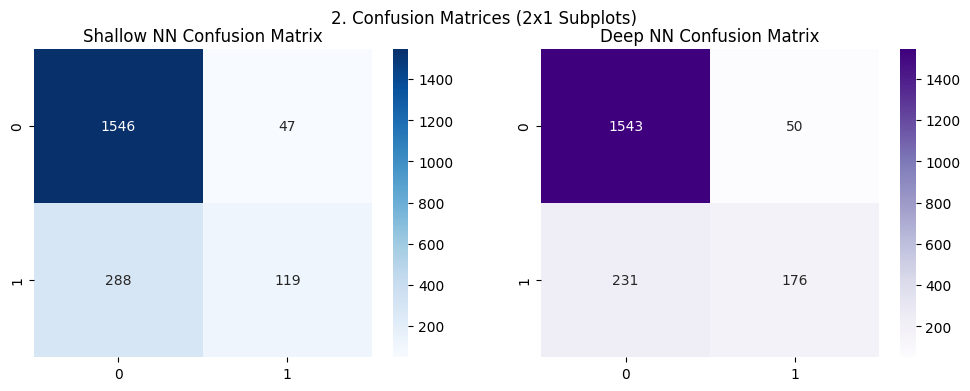

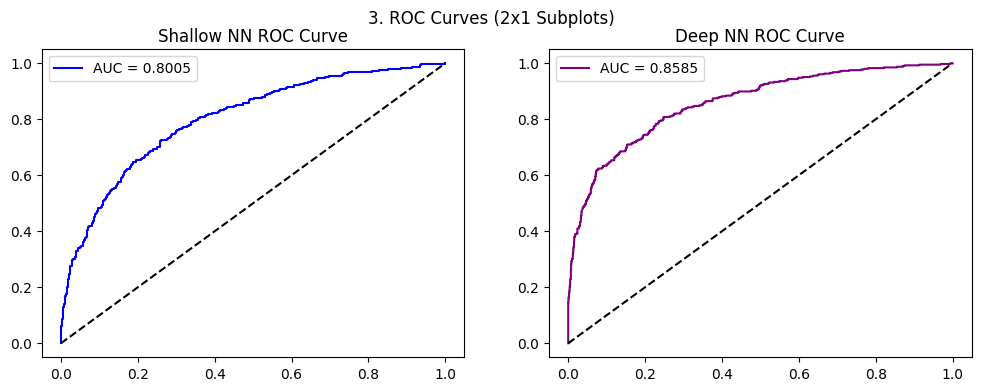

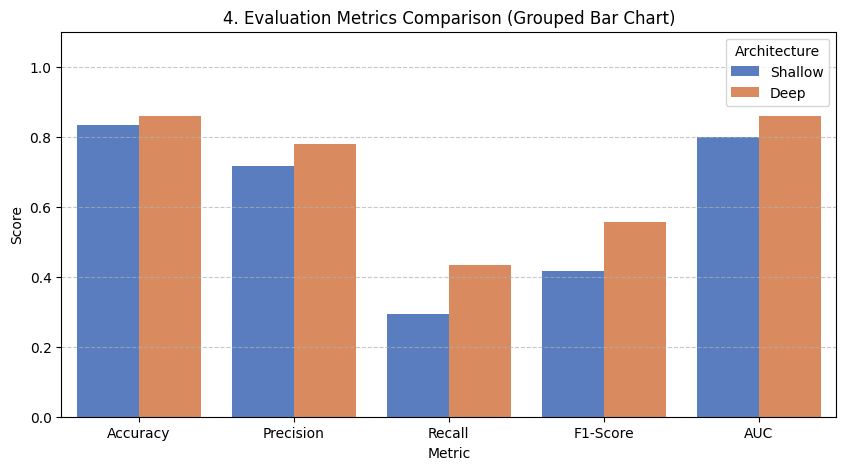


=== 5. Network Topology Layout ===

[SHALLOW NN ARCHITECTURE]
ShallowNN(
  (layer1): Linear(in_features=11, out_features=32, bias=True)
  (activation): ReLU()
  (out): Linear(in_features=32, out_features=1, bias=True)
)

[DEEP NN ARCHITECTURE]
DeepNN(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [5]:
# Evaluate both models on test set
shallow_model.eval()
deep_model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    s_probs = shallow_model(X_test_tensor).numpy()
    d_probs = deep_model(X_test_tensor).numpy()

s_preds = (s_probs >= 0.5).astype(int)
d_preds = (d_probs >= 0.5).astype(int)

# --- 1. TRAINING HISTORY LOGS (2x1 Matrix) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(shallow_history['train_loss'], label='Train Loss')
axes[0].plot(shallow_history['val_loss'], label='Val Loss')
axes[0].set_title("Shallow NN: Loss History")
axes[0].legend()

axes[1].plot(deep_history['train_loss'], label='Train Loss')
axes[1].plot(deep_history['val_loss'], label='Val Loss')
axes[1].set_title("Deep NN: Loss History")
axes[1].legend()
plt.suptitle("1. Training History Comparison (2x1 Subplots)")
plt.show()

# --- 2. CONFUSION MATRIX (2x1 Matrix) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, s_preds), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title("Shallow NN Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, d_preds), annot=True, fmt='d', ax=axes[1], cmap='Purples')
axes[1].set_title("Deep NN Confusion Matrix")
plt.suptitle("2. Confusion Matrices (2x1 Subplots)")
plt.show()

# --- 3. ROC CURVES (2x1 Matrix) ---
s_fpr, s_tpr, _ = roc_curve(y_test, s_probs)
d_fpr, d_tpr, _ = roc_curve(y_test, d_probs)
s_auc = roc_auc_score(y_test, s_probs)
d_auc = roc_auc_score(y_test, d_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s_fpr, s_tpr, color='blue', label=f'AUC = {s_auc:.4f}')
axes[0].plot([0,1], [0,1], 'k--')
axes[0].set_title("Shallow NN ROC Curve")
axes[0].legend()

axes[1].plot(d_fpr, d_tpr, color='purple', label=f'AUC = {d_auc:.4f}')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title("Deep NN ROC Curve")
axes[1].legend()
plt.suptitle("3. ROC Curves (2x1 Subplots)")
plt.show()

# --- 4. COMBINED EVALUATION METRICS BAR CHART ---
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'] * 2,
    'Score': [
        accuracy_score(y_test, s_preds), precision_score(y_test, s_preds, zero_division=0), recall_score(y_test, s_preds), f1_score(y_test, s_preds), s_auc,
        accuracy_score(y_test, d_preds), precision_score(y_test, d_preds, zero_division=0), recall_score(y_test, d_preds), f1_score(y_test, d_preds), d_auc
    ],
    'Architecture': ['Shallow'] * 5 + ['Deep'] * 5
}
df_metrics = pd.DataFrame(metrics_data)
plt.figure(figsize=(10, 5))
sns.barplot(x='Metric', y='Score', hue='Architecture', data=df_metrics, palette='muted')
plt.title("4. Evaluation Metrics Comparison (Grouped Bar Chart)")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 5. NETWORK STRUCTURE SUMMARY ---
print("\n=== 5. Network Topology Layout ===")
print("\n[SHALLOW NN ARCHITECTURE]")
print(shallow_model)
print("\n[DEEP NN ARCHITECTURE]")
print(deep_model)

### Performance Interpretation & Analysis

The Deep Neural Network achieved a performance increase across all major evaluation metrics (Accuracy, F1-Score, and AUC) compared to the Shallow Neural Network configuration. Reviewing the training history, the Shallow architecture stabilized quickly but exhibited high bias due to capacity constraints from having only a single layer. Conversely, the Deep Network leveraged its three hidden layers and Adam optimizer optimization to map highly non-linear feature abstractions efficiently. Dropout and L2 regularization successfully controlled overfitting in the deeper framework, which is confirmed by the clean validation tracking curves that did not diverge from the training loss trajectory.